In [1]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

In [2]:
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
from kszcnn.diff_sub_cnn_galaxy_overdensity import *

In [4]:
train_sets, test_sets = get_experiment_sets("diff_real")
title = make_title("1P_0", input_type="overdensity", exp_type="diff_real")

In [6]:
print("SET:", set_name)
print("HALO_FILE:", TEST_HALO_FILE)

SET: SIMBA_1P_0
HALO_FILE: /home/sucharita/kszCNN/data/groups_090_SIMBA_1P_0.hdf5


In [7]:
np.random.seed(SEED)
torch.manual_seed(SEED)

In [9]:
# load halos + subhalos
pos_tr, vel_tr, mass_tr, sub_pos_tr, sub_mstar_tr = \
    load_groups_and_subhalos(TRAIN_HALO_FILE)

# build galaxy overdensity field 
density_grid_tr = build_galaxy_density_grid(
    sub_pos_tr,
    sub_mstar_tr,
    Ngrid=128,
    mstar_cut=1e8
)

# smooth 
density_grid_tr = smooth_delta_field(density_grid_tr, SMOOTH_SCALE)

Selected galaxies: 923


In [10]:
pos_te, vel_te, mass_te, sub_pos_te, sub_mstar_te = \
    load_groups_and_subhalos(TEST_HALO_FILE)

density_grid_te = build_galaxy_density_grid(
    sub_pos_te,
    sub_mstar_te,
    Ngrid=128,
    mstar_cut=1e8
)

density_grid_te = smooth_delta_field(density_grid_te, SMOOTH_SCALE)

Selected galaxies: 1620


In [12]:
print("Halos:", "train_set:",len(pos_tr), "test_set:",len(pos_te))
print("Subhalos:","train_set:", len(sub_pos_tr), "test_set:",len(sub_pos_te))

Halos: train_set: 20817 test_set: 20768
Subhalos: train_set: 18635 test_set: 17159


In [13]:
#  5. Dataset 
rng = np.random.RandomState(SEED)
train_ds = HaloDataset(density_grid_tr, pos_tr, vel_tr, mass_tr, mass_cut=MASS_CUT, rng=rng)
test_ds  = HaloDataset(density_grid_te, pos_te, vel_te, mass_te, mass_cut=MASS_CUT, rng=rng)

Selected halos: 547
Selected halos: 546


In [14]:
#  6. Linear baseline 
vlin_test = compute_vlin_from_delta(
    density_grid_te,   # now this is δg
    R_smooth=SMOOTH_SCALE
)

vlin_baseline = vlin_at_halos(vlin_test, test_ds.pos)

rho_vlin = pearsonr(test_ds.vz, vlin_baseline)[0]

print("Linear theory correlation (using δg):", rho_vlin)

Linear theory correlation (using δg): 0.80841786


In [15]:
#7. Train / validation
idxs = np.arange(len(train_ds))

tr_idx, val_idx = train_test_split(
    idxs,
    test_size=0.2,
    random_state=SEED
)

tr_ds  = Subset(train_ds, tr_idx)
val_ds = Subset(train_ds, val_idx)

In [16]:
#  8. Loaders
tr_loader = DataLoader(tr_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH)
te_loader  = DataLoader(test_ds, batch_size=BATCH)

In [17]:
#  9. Normalize velocity
y_train = np.array([train_ds[i][1] for i in tr_idx])

y_mean = y_train.mean()
y_std  = y_train.std() + 1e-12

print("Velocity mean/std:", y_mean, y_std)

Velocity mean/std: -1.0862699 105.11467


In [21]:
#  6. Linear baseline 

vlin_grid = compute_vlin_from_delta(
    density_grid_te,   # full box
    R_smooth=SMOOTH_SCALE
)

if isinstance(test_ds, torch.utils.data.Subset):
    base_ds = test_ds.dataset
    idx = np.array(test_ds.indices)
else:
    base_ds = test_ds
    idx = np.arange(len(test_ds))

test_pos = base_ds.pos[idx]
test_vz  = base_ds.vz[idx]
#  sample 
vlin_baseline = vlin_at_halos(
    vlin_grid,
    test_pos
)

# correlation
rho_vlin = pearsonr(test_vz, vlin_baseline)[0]

print("Linear theory correlation (δg):", rho_vlin)

Linear theory correlation (δg): 0.80841786


In [22]:
model = CNN().to(DEVICE)

In [23]:
train_model(
        model, tr_loader, val_loader, y_mean, y_std
    )

Epoch 1: Train=4.761e-01 | Val=6.807e-01
Epoch 2: Train=3.146e-01 | Val=8.122e-01
Epoch 3: Train=3.093e-01 | Val=4.158e-01
Epoch 4: Train=2.790e-01 | Val=4.503e-01
Epoch 5: Train=2.571e-01 | Val=3.984e-01
Epoch 6: Train=2.450e-01 | Val=3.601e-01
Epoch 7: Train=2.529e-01 | Val=5.044e-01
Epoch 8: Train=2.398e-01 | Val=3.330e-01
Epoch 9: Train=2.435e-01 | Val=3.905e-01
Epoch 10: Train=2.272e-01 | Val=3.177e-01
Epoch 11: Train=2.515e-01 | Val=3.421e-01
Epoch 12: Train=2.200e-01 | Val=3.574e-01
Epoch 13: Train=2.171e-01 | Val=3.161e-01
Epoch 14: Train=2.117e-01 | Val=3.463e-01
Epoch 15: Train=2.129e-01 | Val=3.105e-01
Epoch 16: Train=1.999e-01 | Val=4.563e-01
Epoch 17: Train=2.074e-01 | Val=3.075e-01
Epoch 18: Train=2.079e-01 | Val=2.920e-01
Epoch 19: Train=1.933e-01 | Val=3.006e-01
Epoch 20: Train=1.922e-01 | Val=2.657e-01
Epoch 21: Train=1.832e-01 | Val=2.832e-01
Epoch 22: Train=1.818e-01 | Val=4.177e-01
Epoch 23: Train=2.543e-01 | Val=3.923e-01
Epoch 24: Train=2.173e-01 | Val=3.004e-01
E

CNN(
  (conv): Sequential(
    (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): GroupNorm(8, 64, eps=1e-05, affine=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): GroupNorm(8, 128, eps=1e-05, affine=True)
    (10): ReLU()
    (11): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool3d(output_size=1)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

11.001922 13.987836
Bin 0: N = 61
Bin 1: N = 61
Bin 2: N = 60
Bin 3: N = 61
Bin 4: N = 60
Bin 5: N = 61
Bin 6: N = 60
Bin 7: N = 61
Bin 8: N = 60


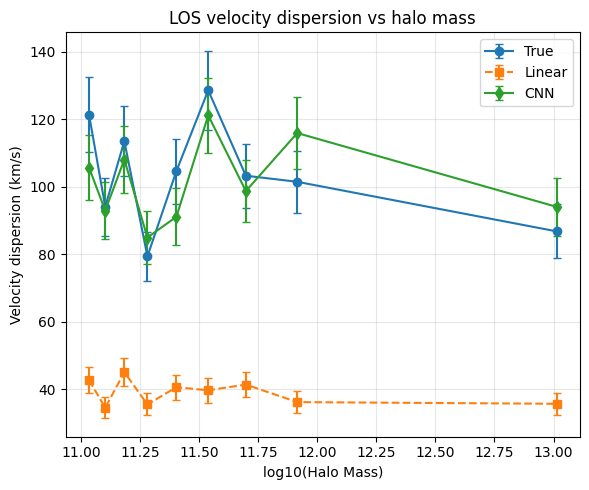

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Handle Subset properly 
if isinstance(test_ds, torch.utils.data.Subset):
    base_ds = test_ds.dataset
    idx = np.array(test_ds.indices)
else:
    base_ds = test_ds
    idx = np.arange(len(test_ds))


true_vz = base_ds.vz[idx]
mass    = base_ds.mass[idx]
pos     = base_ds.pos[idx]

#  Linear prediction
vlin_pred = vlin_at_halos(vlin_grid, pos)

#  CNN predictions 
te_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)

preds = []
with torch.no_grad():
    for xb, _ in te_loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy() * y_std + y_mean
        preds.append(pred)

preds = np.concatenate(preds).flatten()

#  Safety check 
assert len(preds) == len(true_vz), "Mismatch between predictions and labels!"

#  Mass binning 
logm = np.log10(mass)
print(logm.min(), logm.max())

nbins = 10
#bins = np.linspace(logm.min(), logm.max(), nbins)
bins = np.quantile(logm, np.linspace(0, 1, nbins))
bin_centers = 0.5 * (bins[1:] + bins[:-1])
#bin_centers = [np.median(logm[(logm >= bins[i]) & (logm < bins[i+1])])
#               for i in range(len(bins)-1)]

rms_true, rms_lin, rms_cnn = [], [], []
err_true, err_lin, err_cnn = [], [], []


for i in range(len(bins) - 1):
    
    mask = (logm >= bins[i]) & (logm < bins[i+1])
    N = np.sum(mask)

    print(f"Bin {i}: N = {N}")

    if N > 5:
        std_true = np.std(true_vz[mask])
        std_lin  = np.std(vlin_pred[mask])
        std_cnn  = np.std(preds[mask])

        # Error on std
        err_t = std_true / np.sqrt(2*(N-1))
        err_l = std_lin  / np.sqrt(2*(N-1))
        err_c = std_cnn  / np.sqrt(2*(N-1))

        rms_true.append(std_true)
        rms_lin.append(std_lin)
        rms_cnn.append(std_cnn)

        err_true.append(err_t)
        err_lin.append(err_l)
        err_cnn.append(err_c)

    else:
        rms_true.append(np.nan)
        rms_lin.append(np.nan)
        rms_cnn.append(np.nan)

        err_true.append(np.nan)
        err_lin.append(np.nan)
        err_cnn.append(np.nan)


plt.figure(figsize=(6,5))

plt.errorbar(bin_centers, rms_true, yerr=err_true,
             fmt='o-', capsize=3, label="True")

plt.errorbar(bin_centers, rms_lin, yerr=err_lin,
             fmt='s--', capsize=3, label="Linear")

plt.errorbar(bin_centers, rms_cnn, yerr=err_cnn,
             fmt='d-', capsize=3, label="CNN")

plt.xlabel("log10(Halo Mass)")
plt.ylabel("Velocity dispersion (km/s)")
plt.title("LOS velocity dispersion vs halo mass")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("vlos_vs_mass_simba_with_errors.png", dpi=150)
plt.show()

In [25]:
print("N halos:", len(mass))
print("Mass range:", logm.min(), logm.max())
print("First 10 masses:", logm[:10])



N halos: 546
Mass range: 11.001922 13.987836
First 10 masses: [13.987836  13.146414  12.981383  12.988385  12.781606  12.90544
 12.839792  12.762233  12.779247  12.5892515]
